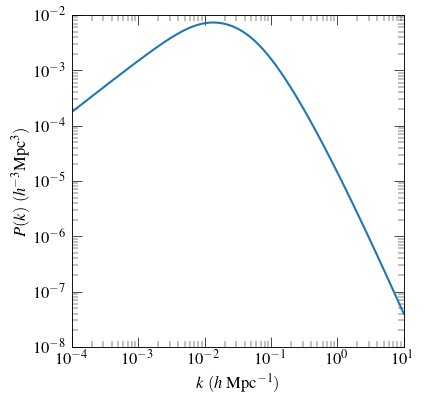

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Define the path to data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"

# Save the plot as a pdf file
PLOT_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Plots/"

# Define the plot style
plt.style.use('MNRAS_Style.mplstyle')
plt.grid(visible=False)

# Define the cosmological parameters
Ohm_m = 0.26
Ohm_b = 0.0435
h = 0.71
n_s = 0.938

const_ps = 1.0

# Define the power spectrum function
def ps(k):
    Gamma = Ohm_m * h * np.exp(-Ohm_b - (2*h)**0.5 * Ohm_b/Ohm_m)
    q = k/Gamma
    tran_fun_a = np.log(1 + 2.34*q)/(2.34*q)
    tran_fun_b = (1 + 3.89*q + (16.1*q)**2 + (5.46*q)**3 + (6.71*q)**4)**(-0.25)
    tran_fun = tran_fun_a * tran_fun_b
    
    return const_ps * k**n_s * tran_fun**2

# Define the k range
k = np.logspace(-4, 1, 1000)

# Plot the power spectrum
plt.plot(k, ps(k))
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k ~ (h ~ \mathrm{Mpc}^{-1})$')
plt.ylabel(r'$P(k) ~ (h^{-3}\mathrm{Mpc}^3)$')
plt.ylim(1e-8, 1e-2)

# Make the plot box square
plt.gca().set_box_aspect(aspect=1)
# plt.xlim(0, 5)
# save the plot as a pdf file
plt.savefig(PLOT_DIRECTORY + 'power_spectrum_Bardeen.pdf')

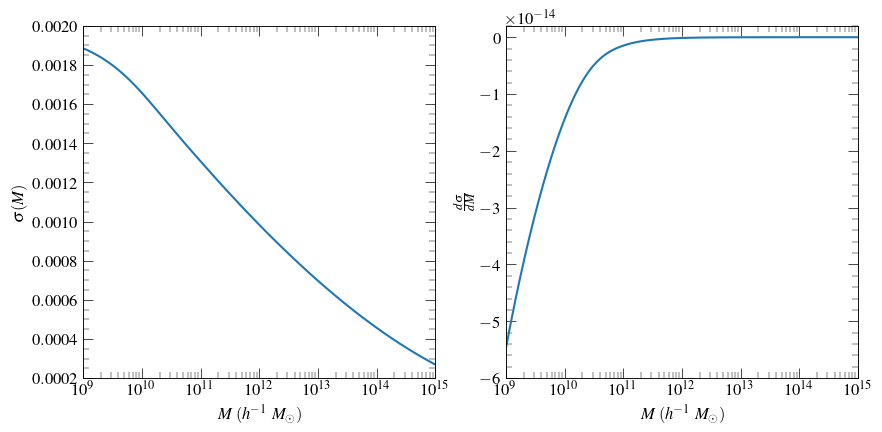

In [59]:
from scipy import integrate

# Define the mean density of the universe at z=0
rho_0 = 2.78e11 * Ohm_m # h^3 h^-1 M_sun/Mpc^3 unit

# Define the spherical top hat filter function
def W(kr):
    return 3*(np.sin(kr) - kr*np.cos(kr))/kr**3

# Define the masses where we want evaluate the halo mass function
M = np.logspace(9, 15, 1000) # h^-1 M_sun unit

# Define the rms linear density fluctuation at the present time smoothed by spherical top hat
def sigma(M):
    kr = k * ((3 * M)/(4 * np.pi * rho_0))**(1/3)
    return (integrate.simps(k**2 * ps(k) * W(kr)**2, k)/(2 * np.pi ** 2))**0.5
vec_sigma = np.vectorize(sigma)

dsigma_dM = np.gradient(vec_sigma(M), M)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Plot the rms linear density fluctuation
ax[0].plot(M, vec_sigma(M))
ax[0].set_xlabel(r'$M ~ (h^{-1} ~ M_{\odot})$')
ax[0].set_ylabel(r'$\sigma(M)$')
ax[0].set_xscale('log')
ax[0].grid(visible=False)
ax[0].set_box_aspect(aspect=1)
ax[0].set_ylim(0.0002, 0.0020)

ax[1].plot(M, dsigma_dM)
ax[1].set_xlabel(r'$M ~ (h^{-1} ~ M_{\odot})$')
ax[1].set_ylabel(r'$\frac{d\sigma}{dM}$')
ax[1].set_xscale('log')
ax[1].grid(visible=False)
ax[1].set_box_aspect(aspect=1)
ax[1].set_ylim(-6e-14, 0.2e-14)

# save the plot as a pdf file
plt.savefig(PLOT_DIRECTORY + 'sigma_dsigma_dM_Shen.pdf')